# Classification de texte avec des RNNs

Dans cette démonstration, nous allons utiliser des RNNs pour retrouver l'auteur d'un texte.

Le corpus utilisé est tiré d'œuvres littéraires classiques de littérature anglophone : 9 auteurs, 2 livres par auteurs avec un fichier par chapitre.

## Téléchargement des données depuis un répo git

In [1]:
!wget -qO- https://github.com/shuuchuu/datasets/raw/refs/heads/main/ghsparse.sh | bash -s classical-authors

remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 1.94 KiB | 1.94 MiB/s, done.
remote: Enumerating objects: 1215, done.
remote: Counting objects: 100% (1215/1215), done.
remote: Compressing objects: 100% (1215/1215), done.
remote: Total 1215 (delta 0), reused 1215 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (1215/1215), 4.22 MiB | 11.13 MiB/s, done.
Updating files: 100% (1215/1215), done.
✓ classical-authors — 1215 fichiers, 12M


## Téléchargement du modèle spacy pour l'anglais

In [2]:
spacy_updated = !pip freeze | grep spacy==3
if not spacy_updated:
  !pip install 'spacy >= 3, < 4'
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 24.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Import de TensorFlow et des autres librairies nécessaires

In [3]:
import re
import typing

import matplotlib.pyplot as plt
import numpy
import pathlib
import seaborn
import sklearn.metrics
import sklearn.model_selection
import sklearn.preprocessing
import spacy
import tensorflow as tf
import tqdm.notebook

### Version courte

La préparation des phrases avec spaCy et les trois entraînements prennent du temps. Pour une démonstration en direct, passez `SHORT_RUN` à `True` dans la cellule suivante : le notebook n'utilise alors qu'un chapitre sur deux, et le dernier modèle s'entraîne pendant `10` itérations au lieu de `30` : le notebook dure alors environ 5 minutes sur un T4, au lieu de 13. Les scores sont alors un peu plus bas (les chiffres cités plus bas sont ceux de la version complète).

In [4]:
SHORT_RUN = False

## Prétraitements

- Chaque phrase est un exemple
- Sont remplacés par leur type (avec la première lettre triplée pour créer de nouveaux « mots ») tout mot (ou groupe de mots) étant une entité nommée

In [5]:
nlp = spacy.load(
    "en_core_web_sm",
    exclude=("tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"))
nlp.enable_pipe("senter")


def replace_ners(tokens: typing.Iterable[spacy.tokens.Token]
                 ) -> typing.Iterator[str]:
  result = []
  for token in tokens:
    if token.ent_iob_ == "O":
      yield token.text
    elif token.ent_iob_ == "B":
      prefix = token.ent_type_[0]
      yield f"{prefix}{prefix}{token.ent_type_}"


def get_data(directory: pathlib.Path,
             ) -> typing.Tuple[typing.List[str], typing.List[str]]:
  texts = []
  authors = []
  paths = sorted(directory.glob("*/*/*.txt"))
  if SHORT_RUN:
    # Un chapitre sur deux de chaque livre.
    paths = paths[::2]
  contents = (p.read_text(encoding="utf8").replace("\n", " ") for p in paths)
  for path, doc in tqdm.notebook.tqdm(zip(paths, nlp.pipe(contents,
                                                          n_process=1)),
                                      total=len(paths)):

    author = path.parent.parent.name
    for sentence in doc.sents:
      authors.append(author)
      texts.append(" ".join(replace_ners(sentence)))

  return texts, authors


texts, authors = get_data(pathlib.Path("classical-authors"))

label_encoder = sklearn.preprocessing.LabelEncoder()
y = label_encoder.fit_transform(authors)

print("Nombre de textes et forme de y :", len(texts), y.shape)

X_train_raw, X_test_raw, y_train, y_test = \
    sklearn.model_selection.train_test_split(texts, y, test_size=0.3)

  0%|          | 0/1214 [00:00<?, ?it/s]

Nombre de textes et forme de y : 74972 (74972,)


In [6]:
print(len(X_train_raw), y_train.shape)

52480 (52480,)


## Préparation des données en séquences



### Préparation du dictionnaire et des séquences

À l'aide de l'outil [`tf.keras.preprocessing.text.Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer), nous allons :
- Constituer un dictionnaire sur le corpus `X_train_raw`
- Chercher la taille du vocabulaire
- Chercher la taille maximale en nombre de mots d'une phrase ?

In [7]:
tokenizer = tf.keras.preprocessing.text.Tokenizer()
tokenizer.fit_on_texts(X_train_raw)

In [8]:
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(s.split()) for s in X_train_raw)
print(f"Taille du vocabulaire : {vocab_size}")
print(f"Taille de la plus grande séquence de mot : {max_length}")

Taille du vocabulaire : 31685
Taille de la plus grande séquence de mot : 530


### Création de la matrice de séquences d'indices

À l'aide des outils [`tf.keras.preprocessing.text.Tokenizer`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/text/Tokenizer) et [`tf.keras.preprocessing.sequence.pad_sequences`](https://keras.io/api/preprocessing/timeseries/#padsequences-function), nous allons :
- Transformer `X_train_raw` et `X_test_raw` en séquences d'indices de mots dans un dictionnaire. (fonction ``texts_to_sequences()`` de l'objet ``Tokenizer`` instancié précédemment)
- Effectuer l'opération de **padding** sur les séquences afin qu'elles aient une taille raisonnable pour être traitées par un GRU bidirectionnel :
  - Utiliser `maxlen = 150` car au-delà les GRU commencent à ne plus être capable de transmettre correctement l'information.
- Stocker les séquences obtenues dans `X_train_pad` et `X_test_pad`

In [9]:
max_length = 150

X_train_tokens = tokenizer.texts_to_sequences(X_train_raw)
X_test_tokens = tokenizer.texts_to_sequences(X_test_raw)

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_tokens, maxlen=max_length, truncating="pre")
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_test_tokens, maxlen=max_length, truncating="pre")

In [10]:
print(f"Forme du corpus de documents : {X_train_pad.shape}")
print(f"Premier exemple : {X_train_pad[0]}")

Forme du corpus de documents : (52480, 150)
Premier exemple : [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0   96  334    5  352    3   44  196   54   25
 1300    4 5147    5  497 4007    6   29   92  935]


## Modélisation

Construisons un modèle avec pour caractéristiques :
  - Une couche d'embeddings de taille 300
  - Une couche de GRU bidirectionnels (Bidirectional est un keras layer):
    - de taille `64`
    - une initialisation **des** matrices de poids orthogonales
    - un paramètre de dropout à `0.2` pour les parties forward
  - Une couche de réseau de neurones à activation `softmax` qui prend en entrée la dernière sortie de la couche [`GRU`](https://keras.io/api/layers/recurrent_layers/gru/)
  - Une fonction de perte basée sur l'**entropie croisée**
  - L'optimiseur `adam`
  - l'`accuracy` comme métrique d'évaluation

In [11]:
EMBEDDING_DIM = 300

model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(max_length,)))
model.add(tf.keras.layers.Embedding(vocab_size, EMBEDDING_DIM))
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(64,
                        kernel_initializer="orthogonal",
                        recurrent_initializer="orthogonal",
                        dropout=0.2)))
model.add(tf.keras.layers.Dense(9, activation="softmax"))
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 150, 300)       │     9,505,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       140,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,647,205 (36.80 MB)

 Trainable params: 9,647,205 (36.80 MB)

 Non-trainable params: 0 (0.00 B)

## Apprentissage

Apprenons notre modèle sur `X_train_pad` :
- avec des batch de taille `1024`
- pendant `10` itérations
- en utilisant 30% de la base d'apprentissage pour validation


In [12]:
model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=10,
          validation_split=0.3)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 11s 145ms/step - accuracy: 0.2426 - loss: 2.0234 - val_accuracy: 0.3090 - val_loss: 1.8605
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.3669 - loss: 1.7210 - val_accuracy: 0.4010 - val_loss: 1.6214
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.5065 - loss: 1.3846 - val_accuracy: 0.4855 - val_loss: 1.4094
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.6394 - loss: 1.0544 - val_accuracy: 0.5367 - val_loss: 1.3005
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.7274 - loss: 0.8208 - val_accuracy: 0.5435 - val_loss: 1.3161
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.7799 - loss: 0.6654 - val_accuracy: 0.5494 - val_loss: 1.3693
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.8198 - loss: 0.5534 - val_accuracy: 0.5514 - val_loss: 1.4335
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - accuracy: 0.8426 - loss: 0.4790 - val_accuracy: 0

## Évaluation

Évaluez les performances de votre modèle sur la base de test.

In [13]:
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, batch_size=1024)
print(f"Accuracy sur la base de test : {test_accuracy:.3f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5519 - loss: 1.5736
Accuracy sur la base de test : 0.552


## Premières conclusions

On observe un phénomène de surapprentissage. train $\approx$ 85% alors que validation et test $\approx$ 55% (version complète)


## Utilisation d'embeddings de mots pré-appris

Afin d'obtenir de meilleurs résultats, nous allons utiliser les embeddings pré-appris GloVe, plutôt que d'apprendre des embeddings spécifiques comme précédemment.

In [14]:
!wget -q https://huggingface.co/stanfordnlp/glove/resolve/main/glove.6B.zip
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       
  inflating: glove.6B.50d.txt        


In [15]:
def glove_path(embedding_dim: int) -> pathlib.Path:
  if embedding_dim in {50, 100, 200, 300}:
    return pathlib.Path("glove.6B.{}d.txt".format(embedding_dim))
  else:
    raise ValueError("embedding_dim must be in {50, 100, 200, 300}")

## Réutilisation des Word Embeddings GloVe

La couche Embedding de Keras peut être initialisée avec une matrice de poids où la ligne i correspond à l'embedding du mot i.

Après un rapide coup d'oeil aux fichiers `glove.6B.300d.txt`, nous allons :
- créer un layer `embedding_layer` de type [`tensorflow.keras.layers.Embedding`](https://keras.io/api/layers/core_layers/embedding/) :
  - l'initialiser avec les embeddings GloVe.
  - initialiser les mots de notre vocabulaire qui ne seraient pas dans GloVe avec le vecteur nul
  - utiliser le flag approprié pour empêcher le changement de ces embeddings pendant l'apprentissage

In [16]:
embedding_matrix = numpy.zeros((vocab_size, EMBEDDING_DIM))
found = 0
with glove_path(EMBEDDING_DIM).open() as fh:
  for line in fh:
    values = line.split(" ")
    word = values[0]
    if word in tokenizer.word_index:
      found += 1
      coeffs = numpy.array(values[1:], dtype="float32")
      embedding_matrix[tokenizer.word_index[word]] = coeffs

print(f"Utilisation de {found} embeddings pré-entraînés sur {vocab_size} mots "
      "dans le vocabulaire")

embedding_layer = tf.keras.layers.Embedding(vocab_size,
                                            EMBEDDING_DIM,
                                            weights=[embedding_matrix],
                                            trainable=False)

Utilisation de 27499 embeddings pré-entraînés sur 31685 mots dans le vocabulaire


## Modélisation, apprentissage et évaluation

Nous allons :

- Créer un modèle identique à celui de la partie précédente, à ceci près que la couche d'embeddings est celle que l'on vient d'instancier à partir de GloVe
- Entraîner ce modèle avec les mêmes paramètres que dans la partie précédente, mais pendant `20` itérations au lieu de `10` : les embeddings figés limitent le surapprentissage, ce qui permet d'entraîner plus longtemps
- L'évaluer sur les données de test

NB : un modèle plus profond, qui fait mieux, est proposé dans la partie suivante.

In [17]:
model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(64,
                        kernel_initializer="orthogonal",
                        recurrent_initializer="orthogonal",
                        dropout=0.2)))
model.add(tf.keras.layers.Dense(9, activation ="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     9,505,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505,500 (36.26 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,505,500 (36.26 MB)

In [18]:
model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=20,
          validation_split=0.3)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.2471 - loss: 2.0448 - val_accuracy: 0.3149 - val_loss: 1.8895
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.3410 - loss: 1.7886 - val_accuracy: 0.3910 - val_loss: 1.6690
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.4105 - loss: 1.6084 - val_accuracy: 0.4451 - val_loss: 1.5358
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.4507 - loss: 1.5128 - val_accuracy: 0.4685 - val_loss: 1.4744
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.4768 - loss: 1.4462 - val_accuracy: 0.4917 - val_loss: 1.4099
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.4946 - loss: 1.3987 - val_accuracy: 0.5037 - val_loss: 1.3753
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.5100 - loss: 1.3580 - val_accuracy: 0.5189 - val_loss: 1.3350
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.5253 - loss: 1.3231 - val_accuracy: 0.52

In [19]:
model.evaluate(X_test_pad, y_test)

703/703 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5802 - loss: 1.1741


[1.1741306781768799, 0.5802062749862671]

## Un modèle plus profond

In [20]:
bidi_gru_params = dict(kernel_initializer="orthogonal",
                       recurrent_initializer="orthogonal",
                       dropout=0.5)

model = tf.keras.models.Sequential()
model.add(embedding_layer)
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(128, **bidi_gru_params, return_sequences=True)))
model.add(tf.keras.layers.Bidirectional(
    tf.keras.layers.GRU(128, **bidi_gru_params)))
model.add(tf.keras.layers.Dense(9, activation="softmax"))

model.compile(loss="sparse_categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 150, 300)       │     9,505,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,505,500 (36.26 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,505,500 (36.26 MB)

In [21]:
scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.1, patience=5)

model.fit(X_train_pad,
          y_train,
          batch_size=1024,
          epochs=10 if SHORT_RUN else 30,
          validation_split=0.3,
          callbacks=[scheduler])

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 16s 346ms/step - accuracy: 0.2683 - loss: 1.9683 - val_accuracy: 0.3459 - val_loss: 1.7504 - learning_rate: 0.0010
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.3674 - loss: 1.7059 - val_accuracy: 0.4317 - val_loss: 1.5627 - learning_rate: 0.0010
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.4204 - loss: 1.5884 - val_accuracy: 0.4682 - val_loss: 1.4674 - learning_rate: 0.0010
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 330ms/step - accuracy: 0.4463 - loss: 1.5195 - val_accuracy: 0.4808 - val_loss: 1.4218 - learning_rate: 0.0010
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 329ms/step - accuracy: 0.4644 - loss: 1.4741 - val_accuracy: 0.5043 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 357ms/step - accuracy: 0.4801 - loss: 1.4379 - val_accuracy: 0.5118 - val_loss: 1.3564 - learning_rate: 0.0010
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 329ms/step - accuracy: 0.4918 - loss: 1.

In [22]:
model.evaluate(X_test_pad, y_test)

703/703 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6068 - loss: 1.1140


[1.1140308380126953, 0.6068379878997803]

## Affichage de la matrice de confusion en Test

Affichons la matrice de confusion (l'utilisation d'une heatmap est recommandée).

In [23]:
y_pred_softmax = model.predict(X_test_pad)
y_pred = numpy.argmax(y_pred_softmax , axis=1)

703/703 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step


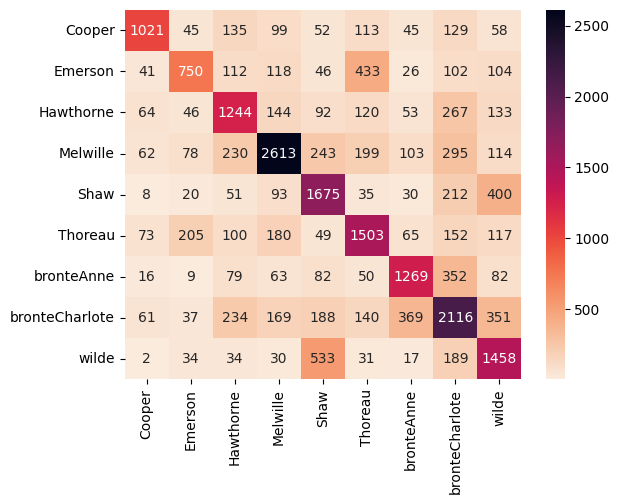

In [24]:
conf_mat = sklearn.metrics.confusion_matrix(y_test, y_pred)
seaborn.heatmap(conf_mat,
                annot=True,
                fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cmap="rocket_r")
plt.show()

## Interprétation

Chiffres de la version complète :

- Le dernier modèle retrouve l'auteur d'**une seule phrase**, souvent très courte, dans environ 62 % des cas. Avec 9 auteurs, répondre au hasard donnerait 11 %, et répondre toujours l'auteur qui a le plus de phrases (Melville) environ 18 % : le modèle a donc bien appris des traits de style.
- La matrice de confusion (lignes : vrai auteur, colonnes : auteur prédit) montre où il se trompe : entre les deux sœurs Brontë, entre Emerson et Thoreau (deux essayistes américains du même courant de pensée), et entre Wilde et Shaw (ici, quatre pièces de théâtre, faites de dialogues). Ses erreurs portent sur des auteurs proches par l'époque, le genre ou le style, comme le seraient celles d'un lecteur.

## À retenir

- Pour un réseau de neurones, un texte est une suite de mots convertis en nombres (des *embeddings*) ; un RNN (ici un GRU) la lit mot à mot.
- Le premier modèle sur-apprend (85 % sur l'entraînement, 55 % en test) : seul compte le score sur des données que le modèle n'a jamais vues.
- Des embeddings pré-appris sur un grand corpus (GloVe), puis un modèle plus profond, font gagner quelques points (de 55 % à 62 % environ).
- Un score se lit par rapport à une référence (le hasard, la classe la plus fréquente), et la matrice de confusion dit quelles classes le modèle confond.
- Pour le texte, les transformers ont depuis largement remplacé les RNN.